# Olist E-Commerce Orders Analysis

## Goal
Analyse an e-commerce order dataset using pandas and build an analysis-ready order-level table.

## Skills practised
- Project-safe file paths
- Loading CSV files
- Data inspection and quality checks
- Missing values and duplicates
- Datetime features
- Filtering and sorting
- Groupby aggregations
- Safe DataFrame merges
- Exporting a processed KPI table
- Basic visualisation

## Important idea: table grain

- `orders`: one row = one order
- `order_items`: one row = one item within an order
- `order_value`: one row = one aggregated order value

I should only merge tables when I understand what one row represents in each table.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def find_project_root(start_path: Path) -> Path:
    """
    Walk upward from the current working directory until we find
    the project folders that identify this repository.
    """
    for candidate in (start_path, *start_path.parents): # here *start_path.parents means 'all parent folders above' so it will go up till it can't or it finds a match
        has_data_folder = (candidate / "data").exists() # for every possible folder check if data folder exists in it
        has_notebooks_folder = (candidate / "notebooks").exists() # check if notebooks folder exists

        if has_data_folder and has_notebooks_folder: # when such a folder is found, return its path
            return candidate

    raise FileNotFoundError( # if nothing found containing said folders, then return Error
        "Could not find the project root. "
        "Make sure the notebook is opened inside market-intelligence-pipeline."
    )


project_root = find_project_root(Path.cwd().resolve())

raw_olist_dir = project_root / "data" / "raw" / "olist" # path specification
processed_olist_dir = project_root / "data" / "processed" / "olist"

raw_olist_dir.mkdir(parents=True, exist_ok=True) # create the folder in the path if it does not exist, i.e. exists_ok=True will make sre we don't get error if folder already is there
processed_olist_dir.mkdir(parents=True, exist_ok=True) # parents=True means if there are empty prent folders to be created, it does that too. e.g. project/data/processed/olist/data.csv


print(f"Project root: {project_root}")
print(f"Raw Olist data: {raw_olist_dir}")
print(f"Processed Olist data: {processed_olist_dir}")

Project root: C:\Users\ozgur\Documents\GitHub\market-intelligence-pipeline
Raw Olist data: C:\Users\ozgur\Documents\GitHub\market-intelligence-pipeline\data\raw\olist
Processed Olist data: C:\Users\ozgur\Documents\GitHub\market-intelligence-pipeline\data\processed\olist


## Data acquisition

The Olist data is downloaded programmatically into `data/raw/olist/`.

Raw source data is not committed to GitHub.
The notebook code is the reproducible instruction for obtaining it.

In [3]:
dataset_handle = 'olistbr/brazilian-ecommerce'

dataset_path = kagglehub.dataset_download(
    dataset_handle,
    output_dir=str(raw_olist_dir),
)

print(f'Dataset downloaded to: {dataset_path}')

100%|██████████| 42.6M/42.6M [00:03<00:00, 12.6MB/s]

Extracting files...


Dataset downloaded to: C:\Users\ozgur\Documents\GitHub\market-intelligence-pipeline\data\raw\olist


In [4]:
csv_files = sorted(raw_olist_dir.rglob("*.csv"))

for csv_file in csv_files:
    print(csv_file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [5]:
def get_raw_file(file_name: str) -> Path:
    """
    Find a file anywhere inside data/raw/olist/.
    """
    matches = list(raw_olist_dir.rglob(file_name)) # search recursively inside raw_olist_dir and every folder below it for a file with a specific name

    if not matches:
        raise FileNotFoundError(
            f"Could not find {file_name} inside {raw_olist_dir}"
        )

    return matches[0]

orders = pd.read_csv(
    get_raw_file("olist_orders_dataset.csv"),
    parse_dates=[ # important when you want to read dates as dates, else they will be read as text, date ops won't be possible
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

order_items = pd.read_csv(
    get_raw_file("olist_order_items_dataset.csv"),
    parse_dates=[
        "shipping_limit_date",
    ],
)

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [7]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
print('orders shape:', orders.shape)
print('order_items shape:', order_items.shape)

orders shape: (99441, 8)
order_items shape: (112650, 7)


In [9]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [10]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


## First inspection questions

Before analysing anything, I need to know:

1. How many rows and columns are there?
2. What does one row represent?
3. Which columns are missing values?
4. Are identifiers unique where I expect them to be?
5. Are the data types appropriate?
6. Are there duplicate rows?

In [ ]:
orders.describe() # include="all" for additional metrics and non numeric columns

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [14]:
order_items.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


In [ ]:
orders.isna().sum().sort_values(ascending=False) # null value check

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

In [17]:
order_items.isna().sum().sort_values(ascending=False)

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [18]:
print('Duplicate rows in orders:', orders.duplicated().sum())
print('Duplicate rows in order_items:', order_items.duplicated().sum())

Duplicate rows in orders: 0
Duplicate rows in order_items: 0


In [ ]:
print("Is order_id unique in orders?")
print(orders["order_id"].is_unique) # this should be True for an orders table, as it should be separable by order id
# order_items["order_id"].is_unique --> this shouldn't be True, since orders can have many order items

Is order_id unique in orders?
True


In [20]:
print("Duplicate order-item combinations:")
print(
    order_items.duplicated(
        subset=["order_id", "order_item_id"]
    ).sum()
)

Duplicate order-item combinations:
0


In [ ]:
orders['order_status'].value_counts(dropna=False) # value_counts returns counts of unique values, so we can see what order status consists of.
# dropna=False forces to include NaN values in frequency count

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [ ]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders[date_columns].isna().sum().sort_values(ascending=False) # check out if there are N/A dates

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

In [ ]:
# let's create a copy of the datasets before working on them, this is usually a good practice when you want to have completely separate, editable sub-tables.
orders = orders.copy()
order_items = order_items.copy()
# a good case could be delivered_orders = orders[orders[order_status] == 'delivered'].copy() --> add columns only for analyzing deliveries

## Datetime features

Dates are usually raw inputs. I create useful business features from them:
- year
- month
- weekday
- delivery duration
- late-delivery indicator

In [25]:
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year

orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype("string")

orders["purchase_day_name"] = orders["order_purchase_timestamp"].dt.day_name()

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,Tuesday


In [26]:
orders["delivery_days"] = ( # create a column for measuring the purchase day - delivery day difference
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [ ]:
orders.loc[ # we use .loc when there is a specific row condition we want to check and find conforming rows
    orders["delivery_days"] < 0,
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_days",
    ],
]

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days


In [29]:
orders['late_delivery'] = pd.NA
# create a mask to check rows, we want to have an actual date and estimated date present so we can find late deliveries
delivery_dates_available = orders['order_delivered_customer_date'].notna() & orders['order_estimated_delivery_date'].notna()

orders.loc[
    delivery_dates_available,
    "late_delivery",
] = (
    orders.loc[
        delivery_dates_available,
        "order_delivered_customer_date",
    ]
    >
    orders.loc[
        delivery_dates_available,
        "order_estimated_delivery_date",
    ]
)

orders["late_delivery"] = orders["late_delivery"].astype("boolean") # python bool only has True, False, but boolean also can rep <NA>

# here, we don't directly use
# orders["late_delivery"] = (
#     orders["order_delivered_customer_date"]
#     > orders["order_estimated_delivery_date"]
# )
# because we want to only account for the rows where both dates are present --> NA should stay NA


In [30]:
orders[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "late_delivery",
    ]
].head(10)

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,late_delivery
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,False
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,False
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,False
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,False
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,False
5,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01,16.0,False
6,2017-04-11 12:22:08,NaT,2017-05-09,NaN,<NA>
7,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07,9.0,False
8,2017-01-23 18:29:09,2017-02-02 14:08:10,2017-03-06,9.0,False
9,2017-07-29 11:55:02,2017-08-16 17:14:30,2017-08-23,18.0,False


## Item-level value

`order_items` is not yet an order-level table.

Each row is one item in an order, so I can calculate an item-level gross value:
price + freight value.

In [31]:
order_items["gross_item_value"] = (
    order_items["price"]
    + order_items["freight_value"]
)

In [32]:
order_items.nlargest(
    10,
    "gross_item_value",
)[
    [
        "order_id",
        "order_item_id",
        "product_id",
        "seller_id",
        "price",
        "freight_value",
        "gross_item_value",
    ]
]

,order_id,order_item_id,product_id,seller_id,price,freight_value,gross_item_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,6735.00,194.31,6929.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,6729.00,193.21,6922.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,6499.00,227.66,6726.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,4799.00,151.34,4950.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,4690.00,74.34,4764.34
62086,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,4590.00,91.78,4681.78
29193,426a9742b533fc6fed17d1fd6d143d7e,1,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,4399.87,113.45,4513.32
56663,80dfedb6d17bf23539beeef3c768f4d7,1,4ca7b91a31637bd24fb8e559d5e015e4,59417c56835dd8e2e72f91f809cd4092,3999.00,195.76,4194.76
45843,68101694e5c5dc7330c91e1bbc36214f,1,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,4099.99,75.27,4175.26
78310,b239ca7cd485940b31882363b52e6674,1,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,4059.00,104.51,4163.51


## Aggregation: convert item-level data to order-level data

I cannot safely merge raw `order_items` into `orders` yet,
because orders may have multiple items.

First, I aggregate item rows so that the result has:
one row = one order.

In [ ]:
order_value = (
    order_items
    .groupby('order_id', as_index=False) # group by what variable, get rows per condition
    .agg(
        gross_order_value=('gross_item_value','sum'), # what are the new columns in the aggregated table
        item_count=('order_item_id','count'),
        average_item_value=('gross_item_value','mean'),
    )
)

order_value.head(15)

,order_id,gross_order_value,item_count,average_item_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,218.04
5,00048cc3ae777c65dbb7d2a0634bc1ea,34.59,1,34.59
6,00054e8431b9d7675808bcb819fb4a32,31.75,1,31.75
7,000576fe39319847cbb9d288c5617fa6,880.75,1,880.75
8,0005a1a1728c9d785b8e2b08b904576c,157.60,1,157.60
9,0005f50442cb953dcd1d21e1fb923495,65.39,1,65.39


In [37]:
print("Rows in order_value:", len(order_value))
print("Unique order IDs:", order_value["order_id"].nunique())
print("Is order_id unique?", order_value["order_id"].is_unique)

Rows in order_value: 98666
Unique order IDs: 98666
Is order_id unique? True


In [ ]:
orders_expanded = orders.merge(
    order_value,
    on='order_id',
    how='left',
    validate='one_to_one', # this means that I expect every order id to appear at most once in both tables, use this when you know the relationship
    indicator=True, # when merging the tables, create a column _merge showing where each resulting row is coming from. you also could name, e.g. indicator=item_data_match
)
# one_to_one, one_to_many, many_to_one, many_to_many

In [ ]:
orders_expanded['_merge'].value_counts() # left_only, right_only, both

_merge
both          98666
left_only       775
right_only        0
Name: count, dtype: int64

In [40]:
orders_expanded = orders_expanded.drop(columns="_merge") # remove column/s

In [44]:
# create analysis-ready deivered orders table
delivered_orders = orders_expanded.loc[(orders_expanded['order_status'] == 'delivered') & orders_expanded['gross_order_value'].notna()].copy()

In [45]:
delivered_orders.shape

(96478, 16)

In [46]:
delivered_orders[
    [
        "order_id",
        "purchase_month",
        "gross_order_value",
        "item_count",
        "delivery_days",
        "late_delivery",
    ]
].head()

,order_id,purchase_month,gross_order_value,item_count,delivery_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,38.71,1.0,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,141.46,1.0,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,179.12,1.0,9.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,72.20,1.0,13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,28.62,1.0,2.0,False


## Order-level KPIs

Now that every row represents one delivered order,
I can safely calculate order counts, total value,
average order value, and delivery metrics.

In [49]:
overall_kpis = pd.Series(
    {
        "delivered_orders": delivered_orders["order_id"].nunique(),
        "gross_order_value": delivered_orders["gross_order_value"].sum(),
        "average_order_value": delivered_orders["gross_order_value"].mean(),
        "median_order_value": delivered_orders["gross_order_value"].median(),
        "average_delivery_days": delivered_orders["delivery_days"].mean(),
        "late_delivery_rate": delivered_orders["late_delivery"].mean(),
    }
)

overall_kpis["late_delivery_rate"] *= 100

overall_kpis

delivered_orders         9.647800e+04
gross_order_value        1.541977e+07
average_order_value      1.598268e+02
median_order_value       1.052800e+02
average_delivery_days    1.209360e+01
late_delivery_rate       8.112367e+00
dtype: float64

In [50]:
monthly_order_kpis = (
    delivered_orders
    .groupby("purchase_month", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        gross_order_value=("gross_order_value", "sum"),
        average_order_value=("gross_order_value", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("late_delivery", "mean"),
    )
)

In [51]:
monthly_order_kpis["late_delivery_rate"] = (
    monthly_order_kpis["late_delivery_rate"] * 100
)

In [52]:
monthly_order_kpis.head()

,purchase_month,delivered_orders,gross_order_value,average_order_value,average_delivery_days,late_delivery_rate
0,2016-09,1,143.46,143.460000,54.000000,100.0
1,2016-10,265,46490.66,175.436453,19.135849,1.132075
2,2016-12,1,19.62,19.620000,4.000000,0.0
3,2017-01,750,127482.37,169.976493,12.092000,3.066667
4,2017-02,1653,271239.32,164.089123,12.606171,3.206292


In [53]:
monthly_order_kpis.nlargest( # look at strongest months
    10,
    "gross_order_value",
)

,purchase_month,delivered_orders,gross_order_value,average_order_value,average_delivery_days,late_delivery_rate
13,2017-11,7289,1153364.20,158.233530,14.699506,14.311196
18,2018-04,6798,1132878.93,166.648857,11.048544,5.310385
19,2018-05,6749,1128774.52,167.250633,10.959105,8.238258
17,2018-03,7003,1120598.24,160.016884,15.867485,21.362273
15,2018-01,7069,1077887.46,152.480897,13.637290,6.56387
21,2018-07,6159,1027807.28,166.878922,8.503736,4.483431
20,2018-06,6099,1011978.29,165.925281,8.774442,1.361549
22,2018-08,6351,985491.64,155.171097,7.286412,10.392064
16,2018-02,6555,966168.41,147.394113,16.508619,15.987796
14,2017-12,5513,843078.29,152.925502,14.936695,8.380192


In [54]:
# I would like to have a group level metric but keep each original row --> transform()
delivered_orders['monthly_average_order_value'] = (
    delivered_orders
    .groupby('purchase_month')['gross_order_value']
    .transform('mean')
)
# group orders by purchase month, calculate the mean gross order valuewithin each month, then return that mean for every original order row
# if we wanted a monthly table and get rid of individial orders, we could use .groupby.agg pattern

In [55]:
delivered_orders["value_vs_month_average"] = (
    delivered_orders["gross_order_value"]
    / delivered_orders["monthly_average_order_value"]
)

delivered_orders[
    [
        "order_id",
        "purchase_month",
        "gross_order_value",
        "monthly_average_order_value",
        "value_vs_month_average",
    ]
].head(10)

,order_id,purchase_month,gross_order_value,monthly_average_order_value,value_vs_month_average
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,38.71,167.734929,0.230781
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,141.46,166.878922,0.847680
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,179.12,155.171097,1.154339
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,72.20,158.233530,0.456288
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,28.62,147.394113,0.194173
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07,175.26,146.254928,1.198319
7,6514b8ad8028c9f2cc2374ded245783f,2017-05,75.16,159.856571,0.470171
8,76c6e866289321a7c93b82b54852dc33,2017-01,35.95,169.976493,0.211500
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07,169.76,146.254928,1.160713
10,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05,259.06,159.856571,1.620578


In [ ]:
output_path = (
    processed_olist_dir
    / "monthly_order_kpis.csv" # name file
)

monthly_order_kpis.to_csv(
    output_path,
    index=False, # True if you want index as a column
)

print(f"Saved processed file to: {output_path}")

Saved processed file to: C:\Users\ozgur\Documents\GitHub\market-intelligence-pipeline\data\processed\olist\monthly_order_kpis.csv


In [57]:
pd.read_csv(output_path).head()

,purchase_month,delivered_orders,gross_order_value,average_order_value,average_delivery_days,late_delivery_rate
0,2016-09,1,143.46,143.460000,54.000000,100.000000
1,2016-10,265,46490.66,175.436453,19.135849,1.132075
2,2016-12,1,19.62,19.620000,4.000000,0.000000
3,2017-01,750,127482.37,169.976493,12.092000,3.066667
4,2017-02,1653,271239.32,164.089123,12.606171,3.206292


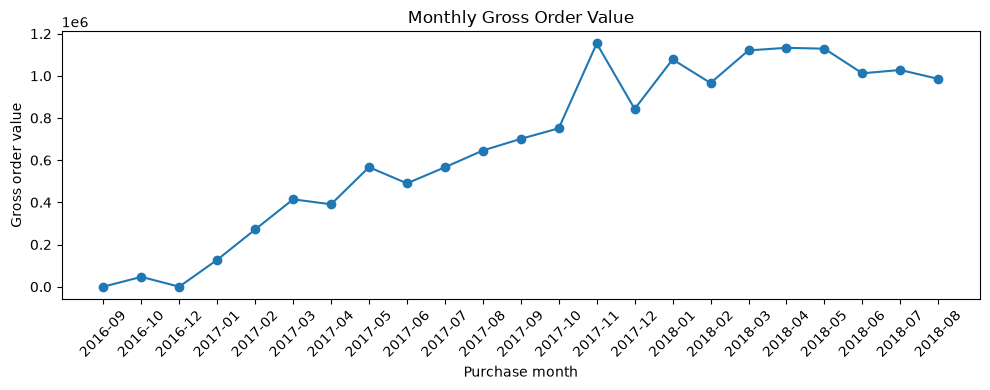

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4)) # create a blank chart (width, height) in inches
# fig is the whole image with whitespaces, ax is the area to plot

ax.plot( # then draw something on the chart, e.g. plot --> define the axes: ax.plot(x_values, y_values) for bar, ax.bar(categories, values) ax.scatter(x, y, alpha, s) alpha for transparency, s for size
    monthly_order_kpis["purchase_month"],
    monthly_order_kpis["gross_order_value"],
    marker="o", # add a small circle at each data point so chart doesn't look like a continuous line, e.g. 'o' for circle, '^' for triangle, 'x' for cross, 's' for square
    # linestyle='--',
    # linewidth=2,
)

ax.set_title("Monthly Gross Order Value") # define labels and titles
ax.set_xlabel("Purchase month")
ax.set_ylabel("Gross order value")
ax.tick_params(axis="x", rotation=45) # rotate labels, in this example 45 degrees for x axis labels

plt.tight_layout() # ask mathplotlib to automatically fix spacing so no overlapping is seen - avoid clips etc.
plt.show()

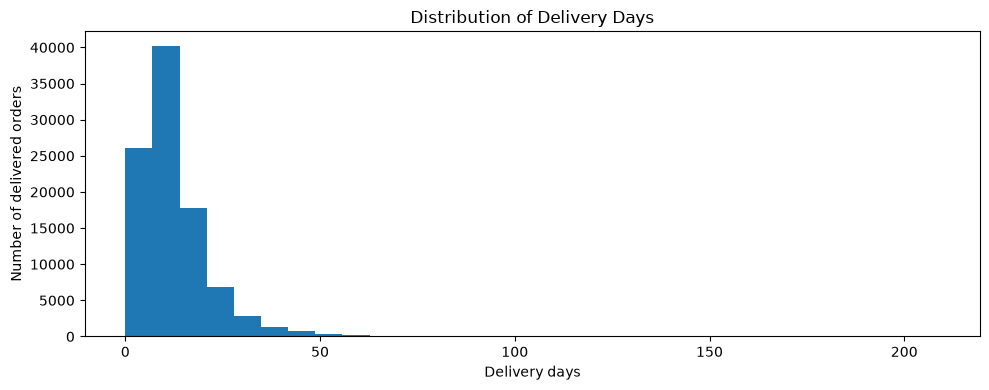

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4)) # create a blank chart

ax.hist( # then draw something on that chart, e.g. histogram
    delivered_orders["delivery_days"].dropna(), # select column to make histogram of, drop na! because histogram can only group numeric values
    bins=30, # how  many intervals/bins do you want?
    # density=True,
    # cumulative=False
    # histtype='bar','step','stepfilled'
)
# it is possible to use custom bins: custom_bins = [0, 2, 5, 10, 15, 20, 30, 45, 60, 90], bins=custom_bins bins will be 0-2, 2-5, 5-10...
ax.set_title("Distribution of Delivery Days")
ax.set_xlabel("Delivery days")
ax.set_ylabel("Number of delivered orders")

plt.tight_layout()
plt.show()

In [ ]:
counts, bin_edges, patches = ax.hist( # find which bins have been used
    delivered_orders["delivery_days"].dropna(),
    bins=30,
)

bin_edges

# there are other bins= combinations: bins='auto', bins='fd' uses the spread of middle 50% of data, could be good for skewed data, 
# bins=np.arrange(0,61,5) use 5 day intervals 0-5, 5-10.. until 55-60

array([  0.        ,   6.96666667,  13.93333333,  20.9       ,
        27.86666667,  34.83333333,  41.8       ,  48.76666667,
        55.73333333,  62.7       ,  69.66666667,  76.63333333,
        83.6       ,  90.56666667,  97.53333333, 104.5       ,
       111.46666667, 118.43333333, 125.4       , 132.36666667,
       139.33333333, 146.3       , 153.26666667, 160.23333333,
       167.2       , 174.16666667, 181.13333333, 188.1       ,
       195.06666667, 202.03333333, 209.        ])